In [4]:
# lime_cnn.ipynb
# Apply LIME to 1D-CNN model
import numpy as np
import pandas as pd
import lime
import lime.lime_tabular
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time

print(f"TensorFloa: {tf.__version__}")
print("Libraries loaded!")

TensorFloa: 2.16.2
Libraries loaded!


In [6]:
# Step 2: Load data and model
print("Loading data and model...")

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_train = pd.read_csv(save_path + "y_train.csv").squeeze()
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()

model = keras.models.load_model(
    save_path + "cnn_model.keras")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("Data and model loaded!")


Loading data and model...
X_train: (1979513, 80)
X_test:  (848363, 80)
Data and model loaded!


In [9]:
# Step 2: Load data and model
print("Loading data and model...")

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"
X_train = np.load(save_path + "X_train.npy")
X_test = np.load(save_path + "X_test.npy")
y_train = pd.read_csv(save_path + "y_train.csv").squeeze()
y_test = pd.read_csv(save_path + "y_test.csv").squeeze()

model = keras.models.load_model(
    save_path + "cnn_model.keras")
print(f"X_train: {X_train.shape}") # f-string
print(f"X_test: {X_test.shape}")
print("Data and model loaded!")


Loading data and model...
X_train: (1979513, 80)
X_test: (848363, 80)
Data and model loaded!


In [12]:
# Step 3: get feature names and class names

import glob  # find files using pattern (like terminal wildcard *)

# set path to all CSV files
path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/cicids_db/*.csv"

files = glob.glob(path)  # list all matching CSV files
df_sample = pd.read_csv(files[0], nrows=5)  # load small sample (first file, 5 rows)

df_sample.columns = df_sample.columns.str.strip()  # clean column names (remove spaces)

# columns to exclude (non-numeric / not features)
non_numeric = ['Flow ID', 'Source IP',
              'Destination IP', 'Timestamp',
              'Label']

# keep only feature columns
feature_names = [c for c in df_sample.columns if c not in non_numeric]

# get class labels from training data
class_names = list(y_train.unique())
class_names.sort()  # sort labels

# print summary info
print(f"Features: {len(feature_names)}")  # number of features
print(f"Classes: {class_names}")         # list of classes


Features: 80
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack']


In [16]:
# Step 4: Create prediction function + LIME explainer
# CNN needs 3D input, but LIME gives flat 2D → reshape handled in predict_fn

def predict_fn(x):
    # reshape (samples, features) → (samples, features, 1)
    x_reshaped = x.reshape(x.shape[0], x.shape[1], 1)
    # run model prediction silently
    return model.predict(x_reshaped, verbose=0)

# Init LIME explainer for tabular data
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,                     
    feature_names=feature_names, # feature names list
    class_names=class_names,     # target labels
    mode='classification',       # task type (classification)
    random_state=42              # fixed seed for reproducibility
)

print("LIME explainer created!")


LIME explainer created!


In [18]:
# Step 5: Explain a BENIGN instance using LIME
print("Explaining BENIGN instance...")

start_time = time.time()  # record start time

# select first test instance and its true label
instance = X_test[0]
true_label = y_test.iloc[0]
print(f"True label: {true_label}")

# run LIME explanation
explanation = explainer.explain_instance(
    instance,      # sample to explain
    predict_fn,    # prediction function
    num_features=10,  # top 10 important features
    num_samples=1000  # number of perturbed samples for LIME
)

end_time = time.time()        # record end time
lime_time = round(end_time - start_time, 2)  # calculate runtime

# print summary
print(f"LIME complete!")
print(f"Time: {lime_time} seconds")
print(f"\nTop 10 features:")
for feature, weight in explanation.as_list():  # show feature weights
    print(f"  {feature}: {weight:.4f}")


Explaining BENIGN instance...
True label: BENIGN
LIME complete!
Time: 2.29 seconds

Top 10 features:
  -0.27 < Bwd IAT Max <= -0.27: 0.0066
  -0.01 < Total Fwd Packets <= -0.01: 0.0029
  Idle Max <= -0.36: -0.0023
  -0.41 < Bwd Packet Length Max <= -0.30: 0.0021
  -0.56 < Average Packet Size <= -0.36: 0.0019
  -0.29 < Flow IAT Mean <= -0.21: 0.0018
  -0.28 < Fwd Packet Length Max <= -0.24: 0.0018
  Init_Win_bytes_backward <= -0.24: -0.0016
  Idle Std <= -0.11: 0.0013
  ECE Flag Count <= -0.02: 0.0004


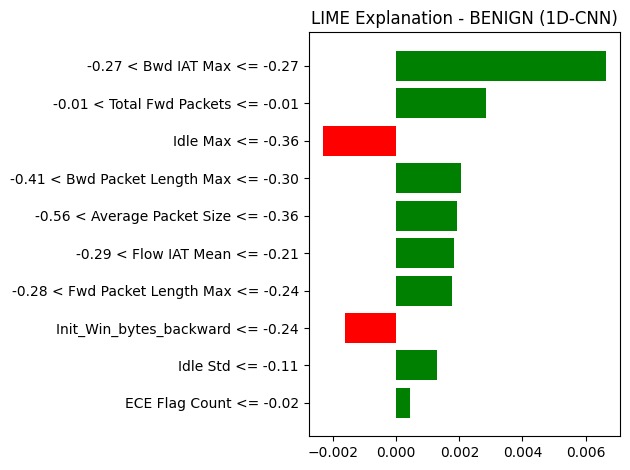

LIME BENIGN plot saved!


In [20]:
# Step 6: Save LIME explanation plot for NEMIGN instance

# Convert LIME explanation to a matplotlib figure 
fig = explanation.as_pyplot_figure()

# add title
plt.title("LIME Explanation - BENIGN (1D-CNN)")

# adjust layout to avoid clipping
plt.tight_layout()

# Save figure as PNG
plt.savefig(
    save_path + "lime_cnn_benign.png", # output file path
    dpi=150,                           # image resolution
    bbox_inches='tight'                # fit layout to content
)

# display plot in notebook/terminal
plt.show()

print("LIME BENIGN plot saved!")


In [23]:
# Step 7: Explain a DDoS instance using LIME
print("Explaining DDoS instance...")

# find first test sample labeled 'DDoS'
ddos_idx = y_test[y_test == 'DDoS'].index[0]
ddos_position = y_test.index.get_loc(ddos_idx)
instance_ddos = X_test[ddos_position]  # get corresponding feature vector

start_time = time.time()  # start timing

# run LIME explanation
explanation_ddos = explainer.explain_instance(
    instance_ddos,  # sample to explain
    predict_fn,     # prediction function
    num_features=10,  # top 10 important features
    num_samples=1000  # number of perturbed samples
)

end_time = time.time()  # end timing

# print results
print(f"True label: DDoS")
print(f"Time: {round(end_time-start_time, 2)}s")
print(f"\nTop 10 features:")
for feature, weight in explanation_ddos.as_list():  # show feature weights
    print(f"  {feature}: {weight:.4f}")


Explaining DDoS instance...
True label: DDoS
Time: 0.5s

Top 10 features:
  -0.68 < ACK Flag Count <= 1.47: 0.0019
  FIN Flag Count <= -0.19: 0.0019
  -0.05 < Subflow Fwd Bytes <= -0.05: -0.0015
  Fwd PSH Flags <= -0.22: 0.0014
  Packet Length Std <= -0.47: 0.0012
  Idle Min > -0.34: -0.0012
  Subflow Bwd Packets <= -0.01: 0.0012
  -0.57 < Min Packet Length <= 0.77: 0.0012
  PSH Flag Count <= -0.65: -0.0011
  Flow IAT Min > -0.06: -0.0011


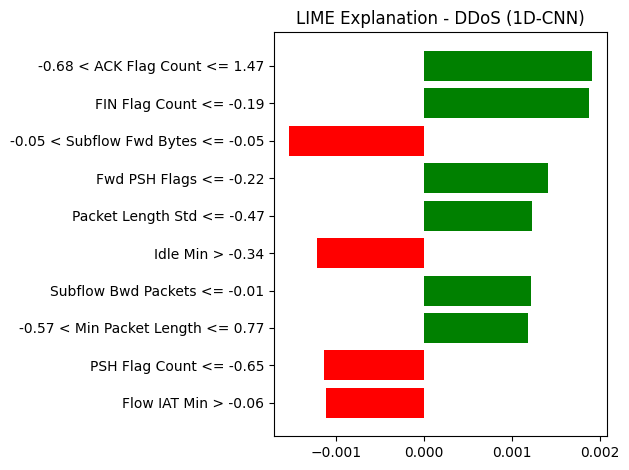

LIME DDoS plot saved!


In [24]:
# Step 8: Save LIME explanation plot for DDoS instance

# convert LIME explanation object to a matplotlib figure
fig = explanation_ddos.as_pyplot_figure()

# add a descriptive title to the plot
plt.title("LIME Explanation - DDoS (1D-CNN)")

# adjust layout to prevent overlapping or clipping of labels
plt.tight_layout()

# Save the figure as a PNG file
plt.savefig(
    save_path + "lime_cnn_ddos.png", # fill output path
    dpi=150,
    bbox_inches='tight' # crop figture tightly around content
)

# display the figure in notebook/terminal
plt.show()

# confirm plot has been saved
print("LIME DDoS plot saved!")

In [25]:
# Step 9: Save LIME results to a JSON file

import json # import JSON library to save results

# organize results into a distionary
lime_cnn_results = {
    "method": "LIME",        # explanation method
    "model": "ID-CNN",       # model type 
    "dataset": "CICIDS2017", # dataset name
    "instance_benign": {     # BENIGN instance details
        "true_label": str(true_label),  # actual label
        "time_seconds": lime_time,      # LIME runtime
        "top_features": explanation.as_list() # top features + weights
    },
    "instance_ddos": {        # DDoS instance details
        "true_label": "DDoS", # actual label
        "top_features": explanation_ddos.as_list() # top features + weights
    }
}

# write results to a JSON file
with open(save_path + "lime_cnn_results.json","w") as f:
    json.dump(lime_cnn_results, f, indent=4) # indent=4 readable format

print("LIME CNN results saved!")

LIME CNN results saved!


In [27]:
# Step 10: Copy generated LIME files to benchmark repository

import shutil # import library for file operations (copy/move)

# set destination folder for benchmark results
benchmark = "/Users/miuyanhong/Desktop/TCSS499_Research_Benchmark/results/"

# copy BENIGN plot to benchmark folder
shutil.copy(
    save_path + "lime_cnn_benign.png", # source file
    benchmark + "lime_cnn_benign.png" # destination path
)

# copy DDoS plot to benchmark folder
shutil.copy(
    save_path + "lime_cnn_ddos.png", # source file
    benchmark + "lime_cnn_ddos.png"  # destination path
)

# copy JSON results to benchmark folder
shutil.copy(
    save_path + "lime_cnn_results.json", # source file
    benchmark + "lime_cnn-results.json"  # destination path
)

print("All files copied!")

All files copied!
